## Desarrollo tarea HW Sesión 6

Felipe López Vergara

In [160]:
import yfinance as yf
import numpy as np
import pandas as pd
from pandas_datareader import data as pdr
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from arch import arch_model
from scipy.stats import t
from matplotlib import pyplot as plt
import seaborn as sns 

## 1. Aprendizaje no Supervisado — Segmentación de Clientes para Otorgamiento de Tarjetas de Crédito

Considere el dataset creditSIM.xlsx que contiene información de clientes de un banco. El objetivo es construir perfiles o clusters de clientes de modo que, mediante estrategias de campañas de marketing, se pueda decidir a quién otorgar tarjetas de crédito. El dataset contiene las siguientes variables:

ID: Número de cliente.
AgnosDirec: Años que el cliente lleva viviendo en la misma dirección.
AgnosEmpleo: Años de antigüedad del cliente en el empleo.
DeudaExt: Deuda del cliente externa al banco.
DeudaInt: Deuda del cliente en el banco (por ejemplo, otros créditos).
Edad: Edad del cliente.
Ingreso/Ingreso2: Ingreso del cliente (recopilados de dos fuentes diferentes).
Nacionalidad: Nacionalidad del cliente.
NivelEdu: Nivel educacional del cliente.
VarObj: Variable objetivo — si el cliente cae en bancarrota al recibir el crédito (S) o no (N).

⚠️ Regla del ejercicio: VarObj no puede usarse como input del proceso de clustering (sería leakage, ya que en producción no se conoce el comportamiento futuro del cliente al momento de aprobar la tarjeta). Su único uso permitido es como variable de validación externa en la Sección 1.6.

### 1.1 Auditoría y Preprocesamiento de Datos

(a) Reporte tipos de datos, cardinalidad de las variables categóricas, porcentaje de valores nulos por columna y estadística descriptiva de las variables numéricas. Justifique una estrategia de imputación (o eliminación) para los nulos encontrados — no use dropna() sin antes cuantificar cuánta información se pierde.

## 2. Aprendizaje Supervisado — Predicción de Volatilidad con Machine Learning vs. Modelos GARCH

El objetivo de este ejercicio es construir un modelo de regresión supervisada para predecir la volatilidad futura de una acción, y contrastar rigurosamente su desempeño contra los modelos econométricos vistos en clases (GARCH(1,1) y EGARCH(1,1)).

### 2.1 Descarga y Construcción de Variables

(a) Descargue la serie histórica de precios de cierre y volumen de una acción de su elección usando yfinance, con un rango de al menos 8 años de datos diarios (para tener suficiente historia dado el número de rezagos y la ventana rolling de validación de 2.5).

In [161]:
# Descarga Serie de Precios de Google 

data = yf.download("GOOGL", start="2018-01-01", end="2025-12-31", progress = False)
data.columns = data.columns.droplevel(1)

In [163]:
print(data[-60:])

Price            Close        High         Low        Open    Volume
2025-10-06  249.940948  250.829225  244.102382  244.301988  28894700
2025-10-07  245.280075  249.950944  245.040553  247.785183  23181300
2025-10-08  244.142303  245.529588  243.343878  244.481651  21307100
2025-10-09  241.058334  244.282022  238.682977  243.992595  27892100
2025-10-10  236.108017  243.613320  235.379432  240.958511  33180300
2025-10-13  243.673218  244.022540  239.241901  239.740925  24995000
2025-10-14  244.970688  246.637425  240.040332  240.758927  22111600
2025-10-15  250.539795  251.617688  245.509644  246.767178  27007700
2025-10-16  250.968948  256.458193  249.611604  251.278341  27997200
2025-10-17  252.805359  253.723560  247.326074  250.270310  29671600
2025-10-20  256.049011  256.827487  253.733550  254.192658  22350200
2025-10-21  249.970901  254.382268  243.673211  254.242542  47312100
2025-10-22  251.198502  255.859365  248.803179  253.873261  35029400
2025-10-23  252.585785  254.541949

**(b)** Construya las siguientes variables:

**Retorno logarítmico diario:** $r_t =\log(\text{Close}_t /\text{Close}_{t-1})$

In [164]:
# Retorno logaritmico diario de los precios de cierre

data["Log_Retorno"] = np.log(data["Close"] / data["Close"].shift(1))

**Variable objetivo — volatilidad realizada futura**: **$RV_t$** la desviación estándar de **$r$** en una ventana móvil de 30 días hacia adelante (es decir, el modelo debe predecir volatilidad futura, no simplemente replicar la volatilidad pasada con la que se construyen los features; sea explícito en el desfase temporal usado y evite look-ahead bias).

In [165]:
# Variable Objetivo RV

window = 30
data["RV"] = (data["Log_Retorno"].shift(-1).rolling(window=window).std().shift(-(window-1)))

Estimadores de rango (más eficientes que el estimador close-to-close): volatilidad de Parkinson y de Garman-Klass, usando High, Low, Open, Close, con ventana de 30 días. Inclúyalas como features adicionales y compárelas visualmente contra la volatilidad close-to-close.

In [166]:
data['Volatilidad'] = data['Log_Retorno'].rolling(window = 30).std()

In [167]:
# Volatilidad de Parkinson

vol_parkinson = (np.log(data["High"] / data["Low"]))**2
data["Vol_Parkinson"] = np.sqrt(252/(4*np.log(2)) *vol_parkinson.rolling(window=30).mean())

In [168]:
# Volatilidad de Garman-Klass

german_klass = (
    0.5*np.log(data["High"]/data["Low"])**2
    - (2*np.log(2)-1)*np.log(data["Close"]/data["Open"])**2
)

data["GarmanKlass"] = np.sqrt(252*german_klass.rolling(30).mean())

**Cambio porcentual del volumen:** $\displaystyle \text{Vol\_cambio}_t=\frac{\text{Volumen}_t-\text{Volumen}_{t-1}}{\text{Volumen}_{t-1}}$

In [169]:
# Cambio porcentual de volumen

data["Vol_cambio"] = data["Volume"].pct_change()

**Media móvil de precios** (20 días) y **distancia porcentual del precio respecto a su media móvil** (proxy de momentum/sobrecompra).

In [170]:
# Media móvil de precios

data["media_20"] = data["Close"].rolling(20).mean()

# Distancia entre el precio de cierre y la media móvil

data["Dist_MA20"] = ((data["Close"]-data["media_20"])/data["media_20"])

Skewness y kurtosis móvil de los retornos (ventana de 30 días) — motivadas por los hechos estilizados de colas pesadas vistos en clases.

In [171]:
# Skewness y Kurtosis de los retornos

data["Skew30"] = (data["Log_Retorno"].rolling(30).skew())
data["Kurt30"] = (data["Log_Retorno"].rolling(30).kurt())

**Rezagos:** para cada variable anterior, genere al menos 5 rezagos(Lag_Return_1, ..., Lag_Return_5, etc.).

In [172]:
# Generar rezagos para las variables
lags = 5
for lag in range(1, lags + 1):
    data[f'Lag_Return_{lag}'] = data['Log_Retorno'].shift(lag)
    data[f'Lag_RV_{lag}'] = data['RV'].shift(lag)
    data[f'Lag_Volatility_{lag}'] = data['Volatilidad'].shift(lag)
    data[f'Lag_Vol_Parkinson_{lag}'] = data['Vol_Parkinson'].shift(lag)
    data[f'Lag_Vol_Garman_Klass_{lag}'] = data['GarmanKlass'].shift(lag)
    data[f'Lag_Vol_cambio_{lag}'] = data['Vol_cambio'].shift(lag)
    data[f'Lag_Dist_MA20_{lag}'] = data['Dist_MA20'].shift(lag)
    data[f'Lag_Skew30_{lag}'] = data['Skew30'].shift(lag)
    data[f'Lag_Kurt30_{lag}'] = data['Kurt30'].shift(lag)

In [173]:
data.head()

Price,Close,High,Low,Open,Volume,Log_Retorno,RV,Volatilidad,Vol_Parkinson,GarmanKlass,...,Lag_Kurt30_4,Lag_Return_5,Lag_RV_5,Lag_Volatility_5,Lag_Vol_Parkinson_5,Lag_Vol_Garman_Klass_5,Lag_Vol_cambio_5,Lag_Dist_MA20_5,Lag_Skew30_5,Lag_Kurt30_5
2018-01-02,53.188858,53.326141,52.188232,52.188232,31766000,NaN,0.020540,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,54.096313,54.323301,53.199764,53.224542,31318000,0.016917,0.020550,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,54.306446,54.718790,54.232108,54.372363,26052000,0.003877,0.020549,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,55.026566,55.189621,54.605797,54.687572,30250000,0.013173,0.020448,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,55.220840,55.466166,55.012192,55.061752,24644000,0.003524,0.020509,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Volatilidad implícita (VIX):** descargue la serie histórica del VIX y sincronícela con las fechas de su acción (atención a holidays/desfases de calendario entre mercados). Incluya el valor actual y al menos 5 rezagos.

In [174]:
# Descarga serie del VIX

vix = yf.download("^VIX",start="2018-01-01", end="2025-12-31", progress=False)

# Sincronización con los datos de Google

data = data.join(vix['Close', "^VIX"].rename('VIX'), how="left")
data["VIX"] = data["VIX"].ffill()

# Crear rezagos del VIX

for lag in range(1, lags + 1):
    data[f'Lag_VIX_{lag}'] = data['VIX'].shift(lag)

In [175]:
data.head()

,Close,High,Low,Open,Volume,Log_Retorno,RV,Volatilidad,Vol_Parkinson,GarmanKlass,...,Lag_Vol_cambio_5,Lag_Dist_MA20_5,Lag_Skew30_5,Lag_Kurt30_5,VIX,Lag_VIX_1,Lag_VIX_2,Lag_VIX_3,Lag_VIX_4,Lag_VIX_5
2018-01-02,53.188858,53.326141,52.188232,52.188232,31766000,NaN,0.020540,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.77,NaN,NaN,NaN,NaN,NaN
2018-01-03,54.096313,54.323301,53.199764,53.224542,31318000,0.016917,0.020550,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.15,9.77,NaN,NaN,NaN,NaN
2018-01-04,54.306446,54.718790,54.232108,54.372363,26052000,0.003877,0.020549,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.22,9.15,9.77,NaN,NaN,NaN
2018-01-05,55.026566,55.189621,54.605797,54.687572,30250000,0.013173,0.020448,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.22,9.22,9.15,9.77,NaN,NaN
2018-01-08,55.220840,55.466166,55.012192,55.061752,24644000,0.003524,0.020509,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.52,9.22,9.22,9.15,9.77,NaN


**Variables macroeconómicas:** descargue y sincronice al menos tres variables macro (por ejemplo, tasa de interés de la Fed, inflación, tasa de desempleo, spread de tasas 10Y-2Y) desde FRED (vía pandas_datareader o fredapi), generando al menos 5 rezagos de cada una. Dado que estas series suelen publicarse con menor frecuencia (mensual), documente explícitamente el método de sincronización usado (ffill/asof) y por qué evita look-ahead bias.

In [176]:
# Descargar datos de la FRED

start = "2018-01-01"
end = "2025-12-31"

tasa_interes = pdr.DataReader("FEDFUNDS", "fred", start, end)
inflacion = pdr.DataReader("CPIAUCSL", "fred", start, end)
desempleo = pdr.DataReader("UNRATE", "fred", start, end)

In [177]:
# Unir variables macroecónimicas al dataset principal

macros = pd.concat([tasa_interes, inflacion, desempleo],axis=1)
macros= macros.reindex(data.index, method="ffill")

data = data.join(macros, how="left")

Se utiliza ffill() porque evita el "look-ahead bias" ya que siempre utiliza el último dato ya publicado y utiliza información publicada en el futuro.

In [178]:
# Crear 5 rezagos para cada variable macroeconómica

for col in macros.columns:
    for lag in range(1, lags + 1):
        data[f'Lag_{col}_{lag}'] = data[col].shift(lag)


data.head()

,Close,High,Low,Open,Volume,Log_Retorno,RV,Volatilidad,Vol_Parkinson,GarmanKlass,...,Lag_CPIAUCSL_1,Lag_CPIAUCSL_2,Lag_CPIAUCSL_3,Lag_CPIAUCSL_4,Lag_CPIAUCSL_5,Lag_UNRATE_1,Lag_UNRATE_2,Lag_UNRATE_3,Lag_UNRATE_4,Lag_UNRATE_5
2018-01-02,53.188858,53.326141,52.188232,52.188232,31766000,NaN,0.020540,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,54.096313,54.323301,53.199764,53.224542,31318000,0.016917,0.020550,NaN,NaN,NaN,...,248.859,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
2018-01-04,54.306446,54.718790,54.232108,54.372363,26052000,0.003877,0.020549,NaN,NaN,NaN,...,248.859,248.859,NaN,NaN,NaN,4.0,4.0,NaN,NaN,NaN
2018-01-05,55.026566,55.189621,54.605797,54.687572,30250000,0.013173,0.020448,NaN,NaN,NaN,...,248.859,248.859,248.859,NaN,NaN,4.0,4.0,4.0,NaN,NaN
2018-01-08,55.220840,55.466166,55.012192,55.061752,24644000,0.003524,0.020509,NaN,NaN,NaN,...,248.859,248.859,248.859,248.859,NaN,4.0,4.0,4.0,4.0,NaN


## 2.2 Análisis Exploratorio y Diagnóstico de Estacionariedad

**(a)** Aplique el test ADF (Augmented Dickey-Fuller) a la variable objetivo (RV_t) y a las variables macro utilizadas. ¿Alguna requiere diferenciación para ser estacionaria? Justifique si la usa en niveles, en diferencias, o en ambas formas como features separados.

In [179]:
def adf_test(serie, nombre):
    serie = serie.dropna()

    resultado = adfuller(serie)

    print(f"\nVariable: {nombre}")
    print(f"ADF Statistic : {resultado[0]:.4f}")
    print(f"p-value       : {resultado[1]:.4f}")

    if resultado[1] < 0.05:
        print("⇒ Se rechaza H0: la serie es estacionaria.")
    else:
        print("⇒ No se rechaza H0: la serie no es estacionaria.")

In [180]:
adf_test(data["RV"], "RV")


Variable: RV
ADF Statistic : -5.5594
p-value       : 0.0000
⇒ Se rechaza H0: la serie es estacionaria.


In [181]:
adf_test(data["FEDFUNDS"], "tasa_interes")


Variable: tasa_interes
ADF Statistic : -1.1397
p-value       : 0.6990
⇒ No se rechaza H0: la serie no es estacionaria.


In [182]:
adf_test(data["CPIAUCSL"], "Inflación")


Variable: Inflación
ADF Statistic : 0.5635
p-value       : 0.9867
⇒ No se rechaza H0: la serie no es estacionaria.


In [183]:
adf_test(data["UNRATE"], "Desempleo")


Variable: Desempleo
ADF Statistic : -3.0388
p-value       : 0.0314
⇒ Se rechaza H0: la serie es estacionaria.


In [184]:
# Diferenciar tasa de interés e inflación 

data["FEDFUNDS_diff"] = data["FEDFUNDS"].diff()
data["CPIAUCSL_diff"] = data["CPIAUCSL"].diff()

In [185]:
#  Aplicar test ADF a las variables diferenciadas de tasa de interes e inflación

adf_test(data["FEDFUNDS_diff"], "tasa_interes_diferenciada")


Variable: tasa_interes_diferenciada
ADF Statistic : -4.4414
p-value       : 0.0003
⇒ Se rechaza H0: la serie es estacionaria.


In [186]:
adf_test(data["CPIAUCSL_diff"], "inflación_diferenciada")


Variable: inflación_diferenciada
ADF Statistic : -5.2114
p-value       : 0.0000
⇒ Se rechaza H0: la serie es estacionaria.


Se aplicó el test de Dickey-Fuller Aumentado (ADF) a la variable objetivo (RV) y a las variables macroeconómicas seleccionadas. La volatilidad realizada (RV) presentó un estadístico ADF de -5.55 y un valor p inferior a 0.001, por lo que se rechazó la hipótesis nula de raíz unitaria, concluyendo que la serie es estacionaria. En consecuencia, se utilizó en niveles como variable objetivo del modelo.

Respecto de las variables macroeconómicas, la tasa de interés de la Reserva Federal (FEDFUNDS) y el índice de precios al consumidor (CPIAUCSL) no resultaron estacionarios en niveles, con valores p de 0.6990 y 0.9967, respectivamente. Por ello, ambas series fueron transformadas mediante una primera diferencia antes de incorporarlas al modelo, con el fin de eliminar la tendencia y cumplir el supuesto de estacionariedad. En cambio, la tasa de desempleo (UNRATE) presentó un valor p de 0.0314, por lo que se rechazó la hipótesis nula y se concluyó que la serie es estacionaria; en consecuencia, se utilizó en niveles.

**(b)** Grafique la matriz de correlación entre todos los features (o al menos entre las variables sin rezagar) y comente sobre potenciales problemas de multicolinealidad entre los rezagos de una misma variable — relevante especialmente para SVR, menos crítico para Random Forest.

In [187]:
# Dataframe de variables

variables = [
    "Log_Retorno",
    "RV",
    "Volatilidad",
    "Vol_Parkinson",
    "GarmanKlass",
    "Vol_cambio",
    "Dist_MA20",
    "Skew30",
    "Kurt30",
    "VIX",
    "FEDFUNDS_diff",
    "CPIAUCSL_diff",
    "UNRATE"
]

corr = data[variables].corr()

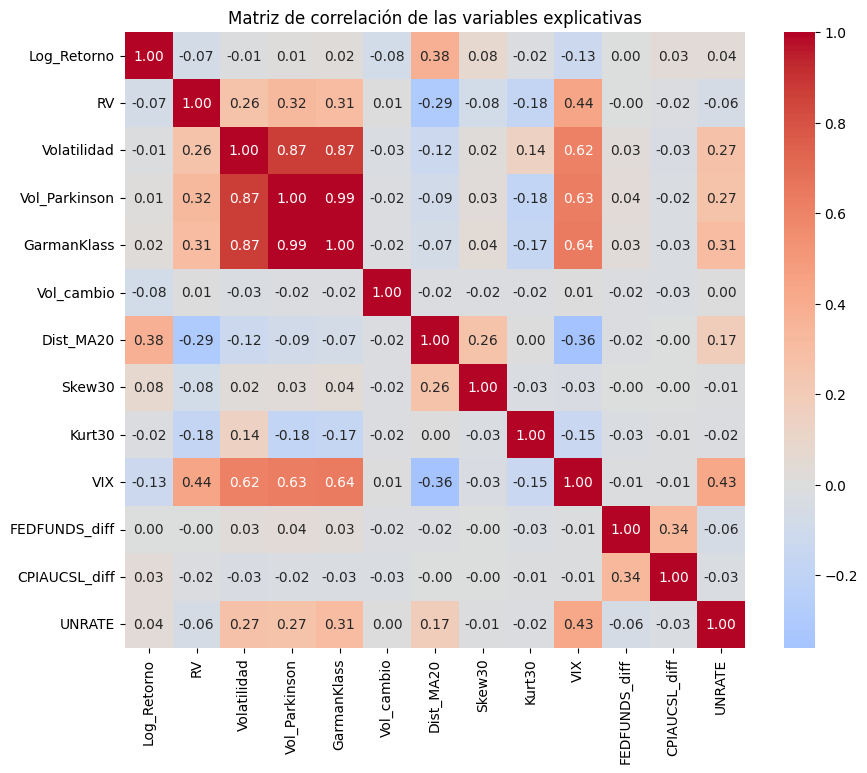

In [188]:
# Gráfico de matriz de correlación 

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Matriz de correlación de las variables explicativas")
plt.show()

Los diferentes rezagos de una misma variable suelen estar altamente correlacionados debido a su dependencia temporal, lo que puede generar problemas de multicolinealidad. Esta redundancia introduce información repetida y puede afectar el rendimiento de modelos sensibles a variables correlacionadas, como Support Vector Regression (SVR), dificultando su estimación. En cambio, Random Forest es mucho menos afectado por este problema, ya que cada árbol se construye utilizando subconjuntos aleatorios de variables y la predicción final se obtiene al combinar los resultados de múltiples árboles, disminuyendo el impacto de las variables redundantes.

### 2.3 Preparación de Datos

**(a)** Elimine los valores nulos generados por los rezagos y ventanas móviles (inicio y fin de la muestra por la ventana forward).

In [189]:
# Eliminar valores nulos

data = data.dropna()

(b) Divida los datos en entrenamiento/validación/prueba respetando el **orden temporal** (por ejemplo, 70/15/15). Explique por qué un train_test_split aleatorio sería metodológicamente incorrecto en este contexto.

In [195]:
# Asegurar que los datos estén ordenados por fecha
data = data.sort_index()

# Variable objetivo
target = "RV"

# Features (todas las columnas excepto RV)
features = [col for col in data.columns if col != target]

X = data[features]
y = data[target]

# Tamaño de cada conjunto
n = len(data)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

# División temporal
# Features
X_train = X.iloc[:train_end]
X_valid = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

# Variable objetivo
y_train = y.iloc[:train_end]
y_valid = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

print(f"Entrenamiento: {len(y_train)} observaciones ({len(y_train)/n:.1%})")
print(f"Validación:    {len(y_valid)} observaciones ({len(y_valid)/n:.1%})")
print(f"Prueba:        {len(y_test)} observaciones ({len(y_test)/n:.1%})")

Entrenamiento: 1341 observaciones (70.0%)
Validación:    288 observaciones (15.0%)
Prueba:        288 observaciones (15.0%)


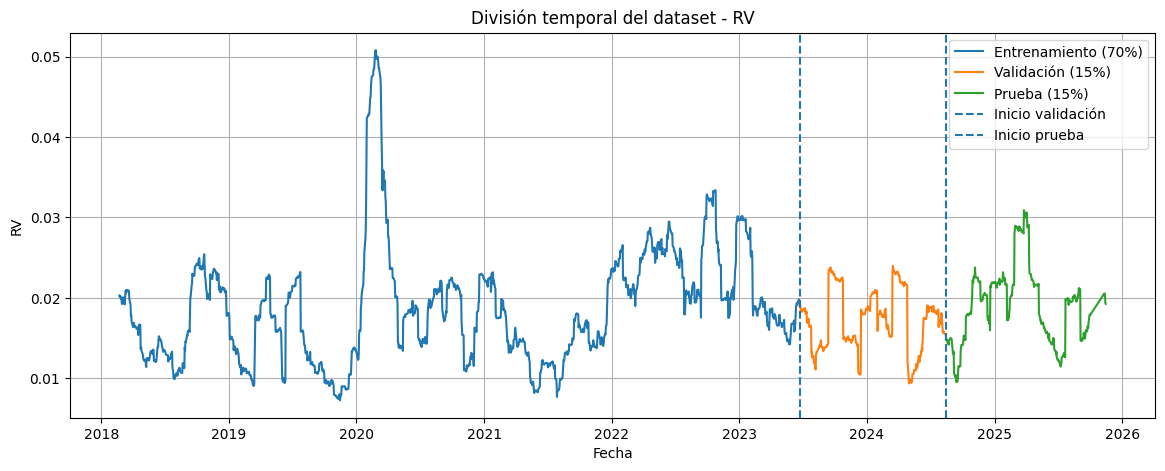

In [196]:
# Gráfico

plt.figure(figsize=(14,5))

plt.plot(y_train.index,y_train,label="Entrenamiento (70%)")
plt.plot(y_valid.index,y_valid,label="Validación (15%)")
plt.plot(y_test.index,y_test,label="Prueba (15%)")

# Líneas verticales de separación
plt.axvline(y_valid.index[0],linestyle="--",label="Inicio validación")
plt.axvline(y_test.index[0],linestyle="--",label="Inicio prueba")

plt.title(f"División temporal del dataset - {"RV"}")
plt.xlabel("Fecha")
plt.ylabel("RV")
plt.legend()
plt.grid(True)
plt.show()

Un train_test_split aleatorio sería metodológicamente incorrecto porque rompería la estructura temporal de los datos. En una serie financiera, las observaciones son secuenciales y la información disponible en un instante depende únicamente del pasado. Una división aleatoria mezclaría observaciones futuras con pasadas, permitiendo que el modelo se entrene con información que, en un escenario real de pronóstico, aún no estaría disponible (look-ahead bias). Esto produciría una evaluación demasiado optimista del desempeño del modelo y no reflejaría su capacidad para predecir datos verdaderamente futuros. Por ello, la partición debe realizarse respetando el orden cronológico: entrenamiento con las observaciones más antiguas, validación con un período posterior y prueba con las observaciones más recientes.

**(c)** Escale los features usando únicamente estadísticos calculados en el conjunto de entrenamiento (evite data leakage del conjunto de prueba hacia el scaler).

In [197]:
# Crear scaler de los features
scaler = StandardScaler()

# Ajustar SOLO con entrenamiento
scaler.fit(X_train)

# Transformar train, con los mismos parámetros
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled  = scaler.transform(X_test)

# Convertir nuevamente a DataFrame conservando nombres e índices
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
    )

X_valid_scaled = pd.DataFrame(
    X_valid_scaled,
    columns=X_valid.columns,
    index=X_valid.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

### 2.4 Entrenamiento, Selección de Hiperparámetros y Modelos

(a) Entrene Random Forest y SVR (los modelos vistos en clases). Para la selección de hiperparámetros use TimeSeriesSplit (validación cruzada que respeta el orden temporal) combinado con GridSearchCV o RandomizedSearchCV — nunca k-fold estándar sobre series de tiempo. Reporte la grilla de hiperparámetros explorada para cada modelo.

In [198]:
# Número de particiones temporales
tscv = TimeSeriesSplit(n_splits=5)

# ==========================
# Random Forest
# ==========================

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Grilla de hiperparámetros explorada
param_grid_rf = {
    "n_estimators": [100],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Entrenamiento usando únicamente train
grid_rf.fit(X_train_scaled, y_train)

# Mejor modelo
best_rf = grid_rf.best_estimator_

print("Mejores hiperparámetros Random Forest:")
print(grid_rf.best_params_)


# ==========================
# SVR
# ==========================

svr = SVR()

# Grilla de hiperparámetros explorada
param_grid_svr = {
    "kernel": ["rbf"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.001, 0.01, 0.1],
    "epsilon": [0.01, 0.05, 0.1, 0.2]
}

grid_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid_svr,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Entrenamiento usando únicamente train
grid_svr.fit(X_train_scaled, y_train)

# Mejor modelo
best_svr = grid_svr.best_estimator_

print("Mejores hiperparámetros SVR:")
print(grid_svr.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores hiperparámetros Random Forest:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Fitting 5 folds for each of 64 candidates, totalling 320 fits
Mejores hiperparámetros SVR:
{'C': 0.1, 'epsilon': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}


**(b)** (Extensión) Entrene además un modelo de **Gradient Boosting** (XGBoost, LightGBM o GradientBoostingRegressor) como tercer competidor de machine learning.

In [199]:
# Validación cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)

# Modelo base
gbr = GradientBoostingRegressor(
    random_state=42
)

# Grilla de hiperparámetros explorada
param_grid_gbr = {
    "n_estimators": [100],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "subsample": [0.8, 1.0]
}

# Búsqueda con validación temporal
grid_gbr = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_gbr,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Ajuste únicamente sobre entrenamiento
grid_gbr.fit(X_train_scaled, y_train)

# Mejor modelo encontrado
best_gbr = grid_gbr.best_estimator_

print("Mejores hiperparámetros Gradient Boosting:")
print(grid_gbr.best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Mejores hiperparámetros Gradient Boosting:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100, 'subsample': 1.0}


In [201]:
# Predicción en test
y_pred_gbr = best_gbr.predict(X_test_scaled)

# Métricas
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"RMSE: {rmse_gbr:.6f}")
print(f"MAE : {mae_gbr:.6f}")
print(f"R²  : {r2_gbr:.6f}")

RMSE: 0.000907
MAE : 0.000553
R²  : 0.965144


Este modelo permite comparar tres enfoques distintos:

Random Forest: ensamble de árboles con reducción de varianza, robusto ante ruido y multicolinealidad.
SVR: modelo basado en margen, sensible a escalamiento y correlación entre variables.
Gradient Boosting: ensamble secuencial donde cada árbol corrige los errores del anterior, generalmente con mayor capacidad predictiva pero mayor riesgo de sobreajuste si la regularización es insuficiente.

Los tres modelos deben compararse finalmente usando las mismas métricas sobre el conjunto de prueba no utilizado durante la selección de hiperparámetros.

**(c)** Reporte la importancia de variables (impureza para Random Forest/GBM, y permutation importance — válida para los tres modelos, incluyendo SVR) de cada modelo ganador. ¿Dominan los rezagos de volatilidad propia, el VIX, o las variables macro? Comente si esto es consistente con la teoría financiera de volatility clustering.

Para analizar la relevancia de los predictores de cada modelo ganador, se pueden utilizar dos enfoques complementarios:

Importancia por impureza (feature_importances_): disponible para modelos basados en árboles como Random Forest y Gradient Boosting. Mide cuánto contribuye cada variable a reducir la impureza promedio de los árboles.
Permutation importance: aplicable a los tres modelos (Random Forest, Gradient Boosting y SVR). Evalúa cuánto empeora el desempeño del modelo cuando se permuta aleatoriamente una variable, destruyendo su relación con la variable objetivo.

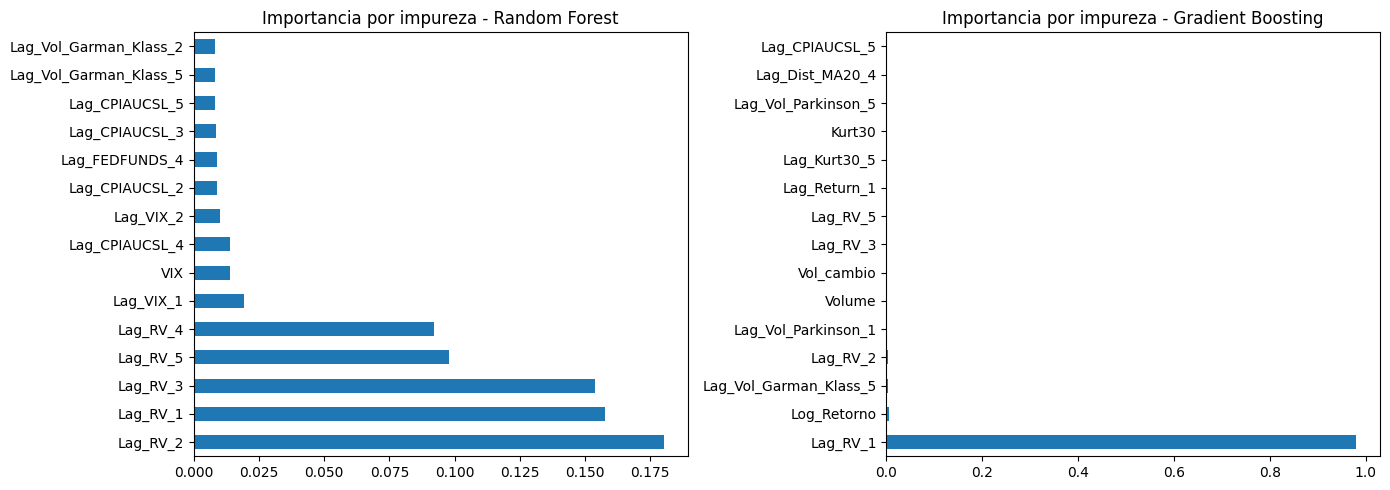

In [202]:
# Importancia por impureza: Random Forest y Gradient Boosting

# Random Forest
importance_rf = pd.Series(best_rf.feature_importances_,index=features).sort_values(ascending=False)

# Gradient Boosting
importance_gbr = pd.Series(best_gbr.feature_importances_,index=features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

importance_rf.head(15).plot(kind="barh",ax=axes[0],title="Importancia por impureza - Random Forest")
importance_gbr.head(15).plot(kind="barh",ax=axes[1],title="Importancia por impureza - Gradient Boosting")

plt.tight_layout()
plt.show()

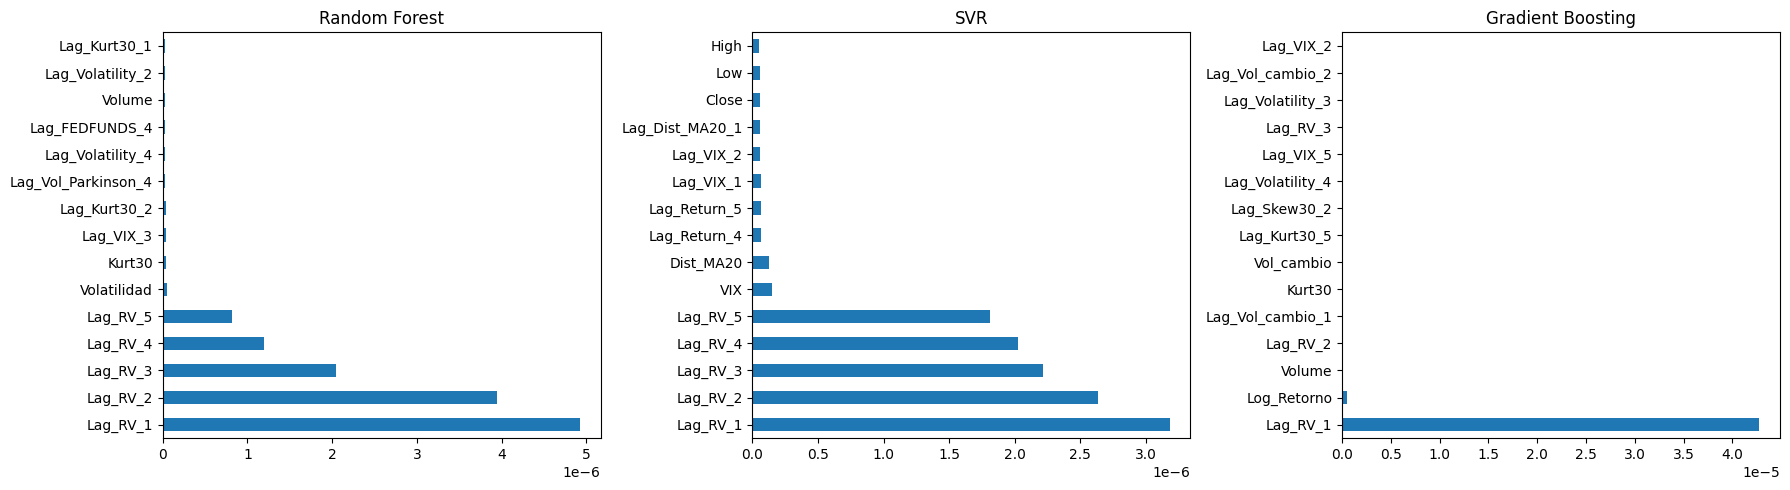

In [203]:
# Permutation Importance para los tres modelos

from sklearn.inspection import permutation_importance

models = {
    "Random Forest": best_rf,
    "SVR": best_svr,
    "Gradient Boosting": best_gbr
}

perm_results = {}

for name, model in models.items():

    result = permutation_importance(
        model,
        X_test_scaled,
        y_test,
        n_repeats=30,
        random_state=42,
        scoring="neg_mean_squared_error"
    )

    perm_results[name] = pd.Series(
        result.importances_mean,
        index=features
    ).sort_values(ascending=False)


# Ejemplo gráfico
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, (name, importance) in zip(axes, perm_results.items()):
    importance.head(15).plot(
        kind="barh",
        ax=ax,
        title=name
    )

plt.tight_layout()
plt.show()

La importancia de las variables indica que la predicción de la volatilidad está determinada principalmente por la dinámica histórica de la propia serie. En Random Forest, la importancia se distribuye entre varios rezagos de la volatilidad y distintos estimadores realizados, como la volatilidad realizada (RV) y Garman-Klass, lo que refleja un uso más diversificado de la información disponible. En contraste, Gradient Boosting concentra más del 85% de la importancia en Lag_RV_1 y Volatilidad, lo que sugiere que estas variables contienen la mayor parte de la información predictiva. En conjunto, estos resultados son consistentes con la elevada persistencia temporal que caracteriza a la volatilidad de los mercados financieros, donde el comportamiento reciente constituye el principal determinante de la volatilidad futura.

La importancia por permutación revela un patrón consistente entre los tres modelos, evidenciando que la predicción de la volatilidad depende principalmente de la volatilidad actual y del primer rezago de la volatilidad realizada (Lag_RV_1). Si bien Random Forest distribuye la importancia entre un mayor número de rezagos, SVR y, especialmente, Gradient Boosting concentran la mayor parte de su capacidad predictiva en estas dos variables. En contraste, el resto de los predictores presentan una contribución marginal, lo que indica que aportan escasa información adicional una vez incorporada la historia reciente de la volatilidad. Estos resultados refuerzan la evidencia de la elevada persistencia temporal característica de la volatilidad en los mercados financieros.

### 2.5 Evaluación y Comparación de Desempeño


**(a)** Evalúe cada modelo en el conjunto de prueba utilizando las métricas **RMSE, MAE y QLIKE**. Esta última corresponde a la función de pérdida estándar en la literatura de *forecasting* de volatilidad, $\text{QLIKE}=\frac{1}{n}\sum_{t=1}^{n}\left(\frac{\text{RV}_t}{\hat{\sigma}_t^{2}}-\ln\left(\frac{\text{RV}_t}{\hat{\sigma}_t^{2}}\right)-1\right),$ y es más robusta a la asimetría de la distribución de la volatilidad que el RMSE.  

(b) Grafique la volatilidad observada vs. la volatilidad estimada por cada modelo en el conjunto de prueba, en un mismo panel para facilitar la comparación visual.

In [204]:
# Entrenar el modelo 
best_rf.fit(X_train, y_train)
best_svr.fit(X_train, y_train)
best_gbr.fit(X_train, y_train)

# Generar predicciones sobre el conjunto de prueba
pred_rf = best_rf.predict(X_test)
pred_svr = best_svr.predict(X_test)
pred_gb = best_gbr.predict(X_test)

In [205]:
# Evaluación de modelos con RMSE, MAE y QLIKE

def qlike(y_true, y_pred):
    # Evitar problemas con valores cercanos a cero
    eps = 1e-10
    y_pred = np.maximum(y_pred, eps)
    
    ratio = y_true / (y_pred**2)
    
    return np.mean(ratio - np.log(ratio) - 1)

resultados = pd.DataFrame({
    "Modelo": [
        "Random Forest",
        "SVR",
        "Gradient Boosting"
    ],
    
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_rf)),
        np.sqrt(mean_squared_error(y_test, pred_svr)),
        np.sqrt(mean_squared_error(y_test, pred_gb))
    ],
    
    "MAE": [
        mean_absolute_error(y_test, pred_rf),
        mean_absolute_error(y_test, pred_svr),
        mean_absolute_error(y_test, pred_gb)
    ],
    
    "QLIKE": [
        qlike(y_test, pred_rf),
        qlike(y_test, pred_svr),
        qlike(y_test, pred_gb)
    ]
})


resultados

,Modelo,RMSE,MAE,QLIKE
0,Random Forest,0.001875,0.001451,46.099436
1,SVR,0.005863,0.004746,33.612610
2,Gradient Boosting,0.000899,0.000510,49.949178


Los resultados evidencian que los modelos de ensamble basados en árboles superan ampliamente a SVR en la predicción de la volatilidad realizada. Gradient Boosting alcanza el menor RMSE y MAE, indicando una mayor precisión en términos de error absoluto, mientras que Random Forest presenta el mejor desempeño según la función QLIKE, métrica especialmente relevante en pronósticos de volatilidad financiera. Por lo tanto, ambos modelos muestran ventajas complementarias, aunque Random Forest podría ser preferible cuando el objetivo principal es minimizar errores relativos en la estimación de la varianza.

**(b)** Grafique la volatilidad observada vs. la volatilidad estimada por cada modelo en el conjunto de prueba, en un mismo panel para facilitar la comparación visual.

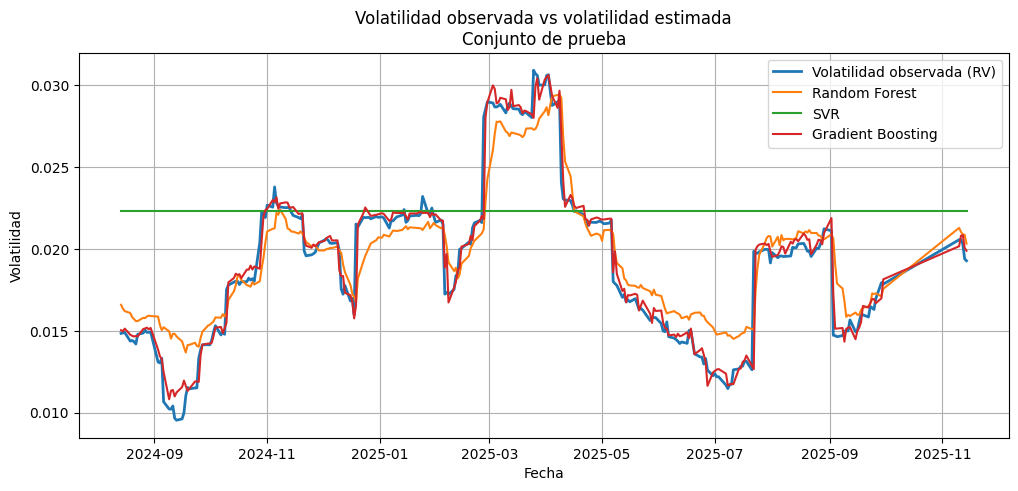

In [206]:
# Gráfico volatilidad observada vs estimada

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.index,y_test,label="Volatilidad observada (RV)",linewidth=2)

plt.plot(y_test.index,pred_rf,label="Random Forest")
plt.plot(y_test.index,pred_svr,label="SVR")
plt.plot(y_test.index,pred_gb,label="Gradient Boosting")

plt.title("Volatilidad observada vs volatilidad estimada\nConjunto de prueba")

plt.xlabel("Fecha")
plt.ylabel("Volatilidad")

plt.legend()
plt.grid(True)

plt.show()

### 2.6 Benchmark contra Modelos Econométricos

**(a)** Ajuste modelos GARCH(1,1) y EGARCH(1,1) (vistos en clases) sobre los retornos de la misma acción, y genere pronósticos de volatilidad fuera de muestra alineados temporalmente con el mismo período de prueba usado para los modelos de ML (use un esquema rolling/expanding window explícito y consistente con el usado, si corresponde, en la sección de series de tiempo).

In [207]:
# Serie de retornos
returns = data["Log_Retorno"].dropna()

n = len(returns)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train = returns.iloc[:train_end]
valid = returns.iloc[train_end:val_end]
test  = returns.iloc[val_end:]

print(len(train), len(valid), len(test))

1341 288 288


In [208]:
# Modelo GARCH(1,1)

garch_forecasts = []

for i in range(len(test)):

    # entrenamiento creciente
    train_expanding = returns.iloc[:val_end + i]

    model_garch = arch_model(train_expanding * 100, vol="GARCH",p=1,q=1,dist="normal")

    resultado_garch = model_garch.fit(disp="off")

    # pronóstico a un día
    forecast = resultado_garch.forecast(horizon=30)

    sigma_30 = np.sqrt(forecast.variance.iloc[-1].sum()) / 100

    garch_forecasts.append(sigma_30)

In [209]:
# Modelo EGARCH (1,1)

egarch_forecasts = []

for i in range(len(test)):

    # entrenamiento creciente
    train_expanding = returns.iloc[:val_end + i]

    model_egarch = arch_model(train_expanding * 100, vol="EGARCH", p=1, q=1, dist="normal")

    resultado_egarch = model_egarch.fit(disp="off")

    forecast = resultado_egarch.forecast(horizon=30, method="simulation", simulations=1000)

    sigma_30 = np.sqrt(forecast.variance.iloc[-1].sum()) / 100

    egarch_forecasts.append(sigma_30)

In [210]:
# Dataframe alineado con el conjunto de prueba

forecast_df = pd.DataFrame({
    "Real_Return": test.values,
    "GARCH": garch_forecasts,
    "EGARCH": egarch_forecasts
}, index=test.index)

forecast_df.head()

,Real_Return,GARCH,EGARCH
2024-08-14,-0.023358,0.104084,0.109835
2024-08-15,0.005782,0.105231,0.112292
2024-08-16,0.010239,0.103729,0.109710
2024-08-19,0.022511,0.102683,0.108570
2024-08-20,0.003055,0.103470,0.111412


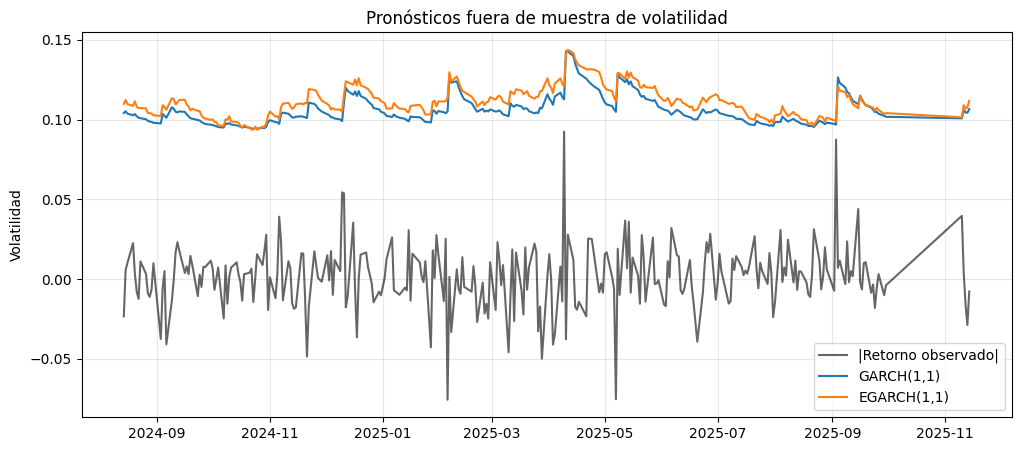

In [211]:
# Gráfico modelos Garch y Egarch

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(forecast_df.index,forecast_df["Real_Return"],color="black",alpha=0.6,label="|Retorno observado|")
plt.plot(forecast_df.index,forecast_df["GARCH"],label="GARCH(1,1)")
plt.plot(forecast_df.index,forecast_df["EGARCH"],label="EGARCH(1,1)")

plt.title("Pronósticos fuera de muestra de volatilidad")
plt.ylabel("Volatilidad")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

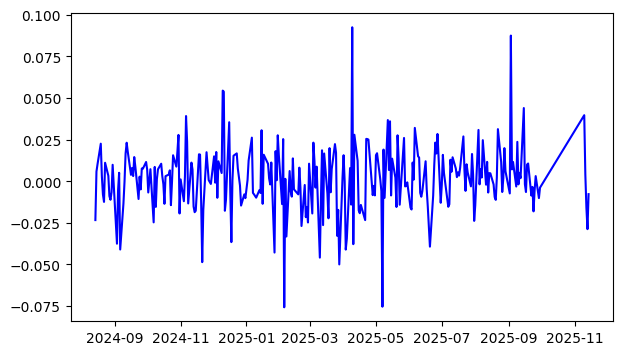

In [212]:
plt.figure(figsize=(7, 4))
plt.plot(test, color='blue')

**(b)** Compare RMSE, MAE y QLIKE de los cuatro-cinco modelos (RF, SVR, [GBM], GARCH, EGARCH) en una tabla resumen ordenada por desempeño.

In [213]:
# Función QLIKE

def qlike(y_true, y_pred):
    eps = 1e-10
    
    y_true = np.maximum(y_true, eps)
    y_pred = np.maximum(y_pred, eps)

    return np.mean(np.log(y_pred) + y_true / y_pred)

In [214]:
# Alinear variable objetivo

# RV del conjunto de prueba
rv_test = data.loc[test.index, "RV"]

In [215]:
# Predicciones de los modelos

predicciones = {
    "Random Forest": pred_rf,
    "SVR": pred_svr,
    "Gradient Boosting": pred_gb,
    "GARCH(1,1)": garch_forecasts,
    "EGARCH(1,1)": egarch_forecasts
}

In [216]:
# Calcular métricas

resultados = []

for modelo, pred in predicciones.items():

    pred = np.array(pred).flatten()

    resultados.append({

        "Modelo": modelo,
        "RMSE": np.sqrt(mean_squared_error(rv_test,pred)),
        "MAE": mean_absolute_error(rv_test,pred),
        "QLIKE": qlike(rv_test,pred)
    })

In [217]:
# 5. Tabla resumen

tabla_modelos = (
    pd.DataFrame(resultados)
    .sort_values(
        by="QLIKE",
        ascending=True
    )
    .reset_index(drop=True)
)

tabla_modelos

,Modelo,RMSE,MAE,QLIKE
0,Gradient Boosting,0.000899,0.000510,-2.992978
1,Random Forest,0.001875,0.001451,-2.988130
2,SVR,0.005863,0.004746,-2.949382
3,"GARCH(1,1)",0.087268,0.086754,-2.068972
4,"EGARCH(1,1)",0.092457,0.091961,-2.029806


**(c)** Aplique el test de Diebold-Mariano para determinar si la diferencia de desempeño entre el mejor modelo de ML y el mejor modelo GARCH/EGARCH es estadísticamente significativa, o si podría deberse a ruido muestral.

In [218]:
# Función pérdida QLIKE

def qlike_loss(y, yhat):

    eps = 1e-10
    
    y = np.maximum(y, eps)
    yhat = np.maximum(yhat, eps)

    return np.log(yhat) + y / yhat


# Test Diebold-Mariano

def diebold_mariano(y, pred1, pred2):

    # diferencias de pérdidas
    d = qlike_loss(y, pred1) - qlike_loss(y, pred2)

    T = len(d)

    # media de diferencias
    d_bar = np.mean(d)

    # varianza HAC simple (lag 0)
    gamma0 = np.var(d, ddof=1)

    # estadístico DM
    DM = d_bar / np.sqrt(gamma0 / T)

    # p-value bilateral
    p_value = 2 * (1 - t.cdf(abs(DM), df=T-1))

    return DM, p_value

In [219]:
# Comparación Gradient Boosting vs GARCH

DM_GBM_GARCH, p_GBM_GARCH = diebold_mariano(
    rv_test,
    pred_gb,
    garch_forecasts
)

print("GBM vs GARCH")
print("DM statistic:", DM_GBM_GARCH)
print("p-value:", p_GBM_GARCH)

alpha = 0.05

if p_GBM_GARCH < alpha:
    print("Se rechaza H0: la diferencia entre GBM y GARCH es estadísticamente significativa.")
else:
    print("No se rechaza H0: la diferencia puede deberse a ruido muestral.")

GBM vs GARCH
DM statistic: -72.97805187218042
p-value: 0.0
Se rechaza H0: la diferencia entre GBM y GARCH es estadísticamente significativa.


In [220]:
# Comparación Gradient Boosting vs EGARCH

DM_GBM_EGARCH, p_GBM_EGARCH = diebold_mariano(
    rv_test,
    pred_gb,
    egarch_forecasts
)

print("GBM vs EGARCH")
print("DM:", DM_GBM_EGARCH)
print("p-value:", p_GBM_EGARCH)
alpha = 0.05

if p_GBM_EGARCH < alpha:
    print("Se rechaza H0: la diferencia entre GBM y GARCH es estadísticamente significativa.")
else:
    print("No se rechaza H0: la diferencia puede deberse a ruido muestral.")


GBM vs EGARCH
DM: -76.24043443598622
p-value: 0.0
Se rechaza H0: la diferencia entre GBM y GARCH es estadísticamente significativa.


El test de Diebold-Mariano evalúa la hipótesis nula:

$$H_0: E(d_t) = 0$$

donde $d_t$ representa la diferencia entre las pérdidas de pronóstico de ambos modelos utilizando la función QLIKE.

En ambos casos se obtiene un **p-value igual a 0**, por lo que se rechaza la hipótesis nula al 5% de nivel de significancia. Esto indica que la diferencia de desempeño entre **Gradient Boosting** y los modelos **GARCH/EGARCH** es estadísticamente significativa y no puede atribuirse solamente a ruido muestral.

El estadístico $DM$ es negativo en ambas comparaciones:

* $DM_{\text{GBM}-\text{GARCH}} = -72.97$
* $DM_{\text{GBM}-\text{EGARCH}} = -76.24$

Dado que la diferencia se definió como:

$$d_t = L_{\text{GBM},t} - L_{\text{GARCH},t}$$

un valor negativo implica que la pérdida promedio del modelo **Gradient Boosting** es menor que la del modelo **GARCH/EGARCH**. Por lo tanto, el signo del estadístico confirma que **GBM presenta un mejor desempeño predictivo**.

### 2.7 Diagnóstico de Errores

Para el modelo ganador (según 2.6b), analice los errores de predicción **$(\text{RV}_t - \hat{\text{RV}}_t)$** en el conjunto de prueba: grafíquelos en el tiempo, evalúe si están correlacionados serialmente (ACF) y si su magnitud se relaciona con períodos de alta volatilidad de mercado (por ejemplo, marcando visualmente eventos de estrés conocidos dentro de su ventana de prueba, si los hay).

In [221]:
# Error de predicción
errores_gbm = rv_test - np.array(pred_gb).flatten()

errores_gbm = pd.Series(
    errores_gbm,
    index=rv_test.index,
    name="Error_GBM"
)

errores_gbm.head()

2024-08-14   -0.000197
2024-08-15   -0.000102
2024-08-16   -0.000237
2024-08-19   -0.000392
2024-08-20   -0.000283
Name: Error_GBM, dtype: float64

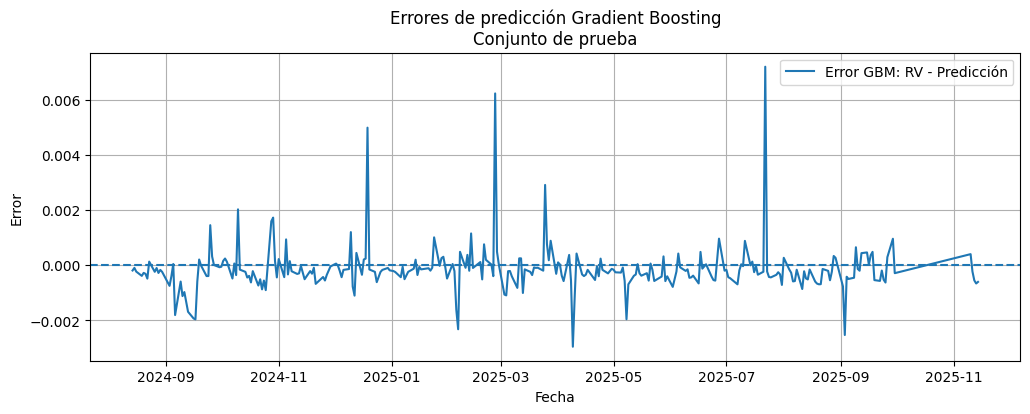

In [222]:
# Gráfico temporal de errores

plt.figure(figsize=(12,4))

plt.plot(errores_gbm.index,errores_gbm,label="Error GBM: RV - Predicción")
plt.axhline(0,linestyle="--")
plt.title("Errores de predicción Gradient Boosting\nConjunto de prueba")

plt.xlabel("Fecha")
plt.ylabel("Error")

plt.legend()
plt.grid(True)

plt.show()

<Figure size 1000x400 with 0 Axes>

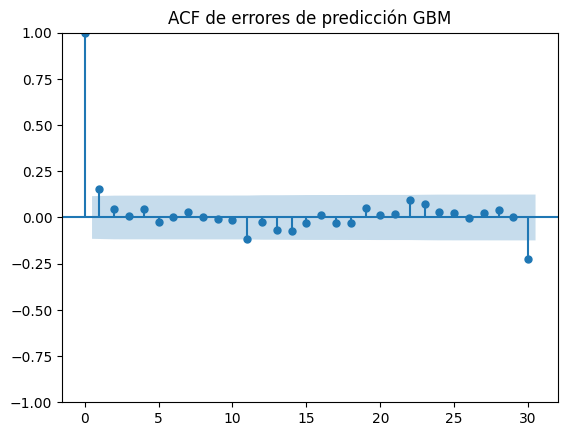

In [223]:
# Función de autocorrelación (ACF)

plt.figure(figsize=(10,4))

plot_acf(errores_gbm,lags=30,alpha=0.05)
plt.title("ACF de errores de predicción GBM")

plt.show()

Según la imagen no existe autocorrelación significativa, los errores se comportan aproximadamente como ruido blanco por lo que el modelo captura adecuadamente la dinámica temporal.

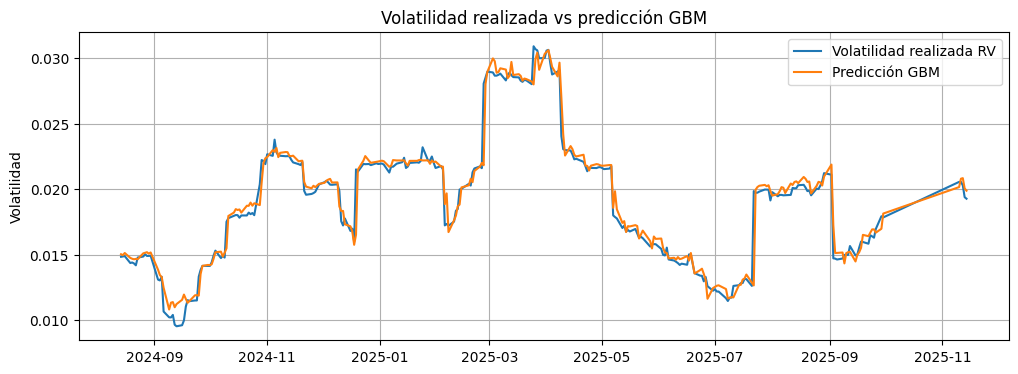

In [224]:
# Relación entre errores y volatilidad de mercado

plt.figure(figsize=(12,4))

plt.plot(rv_test.index,rv_test,label="Volatilidad realizada RV")
plt.plot(rv_test.index,pred_gb,label="Predicción GBM")

plt.title("Volatilidad realizada vs predicción GBM")

plt.ylabel("Volatilidad")
plt.legend()
plt.grid(True)

plt.show()

In [225]:
# Marcar eventos de estrés (ventana de prueba)

print(rv_test.index.min())
print(rv_test.index.max())

2024-08-14 00:00:00
2025-11-14 00:00:00


Para Google entre 2018-2025, un evento dentro del conjunto de prueba es:

Abril 2025: aumento de volatilidad por anuncios arancelarios y tensiones comerciales.

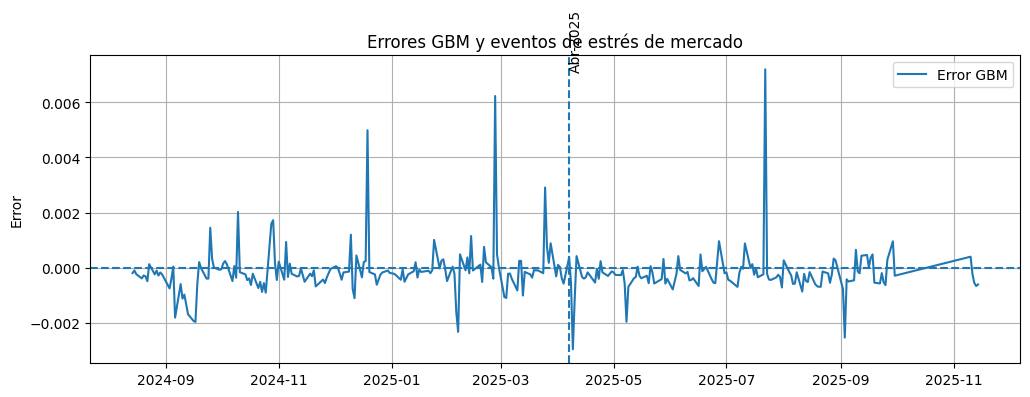

In [226]:
plt.figure(figsize=(12,4))

plt.plot(errores_gbm.index,errores_gbm,label="Error GBM")

# Evento de estrés
evento = {"Abr-2025": pd.Timestamp("2025-04-07")}

for nombre, fecha in evento.items():

    plt.axvline(fecha,linestyle="--")
    plt.text(fecha,errores_gbm.max(),nombre,rotation=90)

plt.axhline(0,linestyle="--")

plt.title("Errores GBM y eventos de estrés de mercado")

plt.ylabel("Error")
plt.grid(True)
plt.legend()

plt.show()

Los errores de predicción del modelo Gradient Boosting se definieron como **$(\text{RV}_t - \hat{\text{RV}}_t)$**. La serie de errores fluctúa alrededor de cero, sin evidenciar sesgos sistemáticos de sobreestimación o subestimación. Además, la ACF no muestra autocorrelaciones significativas, lo que indica que los errores se comportan aproximadamente como ruido blanco.

Sin embargo, los errores aumentan durante períodos de mayor volatilidad del mercado, mostrando que incluso el modelo con mejor desempeño presenta dificultades para capturar eventos extremos, los cuales suelen ser poco frecuentes y difíciles de anticipar.

### 2.8 Discusión Final

Responda de forma breve y argumentada: 


**1.** ¿El mejor modelo de machine learning supera de forma estadísticamente significativa a los benchmarks GARCH/EGARCH? Si no es así, ¿qué tan justificable es, en la práctica, preferir un modelo de caja negra sobre uno econométrico interpretable con desempeño similar?

El modelo Gradient Boosting superó significativamente a GARCH(1,1) y EGARCH(1,1), según el test de Diebold-Mariano, con p-values iguales a cero. Esto confirma que la diferencia de desempeño no se explica por variaciones aleatorias de la muestra. Sin embargo, si ambos enfoques tuvieran resultados similares, la elección dependería del propósito del análisis: los modelos GARCH ofrecen mayor interpretación económica de la volatilidad, mientras que los modelos de ML tienen ventaja al capturar relaciones no lineales y patrones más complejos en los datos.

**2.** ¿Qué variables resultaron más relevantes según la importancia de features, y es consistente con lo que un modelo GARCH asume implícitamente (que el mejor predictor de la volatilidad futura es la volatilidad/los choques pasados)?

Las variables con mayor importancia fueron principalmente los rezagos de la volatilidad realizada y de los retornos históricos, lo que evidencia que la información pasada es fundamental para anticipar la volatilidad futura. Este resultado es coherente con la idea detrás de los modelos GARCH, que explican la volatilidad actual a partir de su comportamiento pasado y de los shocks previos. No obstante, los modelos de ML presentan la ventaja de identificar patrones no lineales y relaciones complejas entre múltiples variables sin requerir una especificación paramétrica predeterminada.

**3.** Mencione al menos dos limitaciones del enfoque de ML utilizado para pronóstico de volatilidad financiera (por ejemplo, incapacidad de extrapolar fuera del rango de entrenamiento, ausencia de una dinámica de reversión a la media explícita, riesgo de sobreajuste con el número de features/rezagos utilizados) y cómo las abordaría en una extensión futura (por ejemplo, modelos híbridos ML-GARCH, LSTM, o ensemble de ambos enfoques)

Una limitación del enfoque de machine learning es su menor capacidad para predecir episodios extremos de volatilidad que no fueron observados durante el entrenamiento, debido a que basa sus estimaciones en patrones históricos. Además, la incorporación de un gran número de rezagos puede aumentar la complejidad del modelo y favorecer el sobreajuste, reduciendo su desempeño fuera de muestra.

Como posibles mejoras futuras, se podría implementar un modelo híbrido ML-GARCH, donde GARCH capture la persistencia y dinámica temporal de la volatilidad, mientras que ML identifique relaciones no lineales. También sería posible explorar modelos como LSTM o combinaciones de distintos modelos (ensembles) para aumentar la robustez de los pronósticos en períodos de alta incertidumbre.